In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.models import resnet101

from torchvision import transforms ,datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report  
)
from torchvision.datasets import ImageFolder
import seaborn as sns
import os
print(torch.__version__)
print(f"GPU: {torch.cuda.is_available()}")
from torch.cuda.amp import autocast, GradScaler

2.2.2+cu121
GPU: True


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Cihaz: {device}")

Cihaz: cuda


In [3]:
BATCH_SIZE = 32 # hər addımda 32 şəkil
LR = 0.0001  # kiçik addımlarla öyrən 
NUM_EPOCHS = 20 #datasetin üzərindən 20 dəfə keç 
IMG_SIZE = 224  # şəkilləri 224×224 et
NUM_CLASSES = 101  # 101 yemək növü 

train_data  = ImageFolder(root='yemek_sekilleri/train')
val_data   = ImageFolder(root='yemek_sekilleri/validation')

print(len(train_data.classes))
print(len(val_data.classes))

print(train_data.classes)
print(val_data.classes)

print(len(train_data))
print(len(val_data))

101
101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', '

In [4]:
temp_dataset = ImageFolder(root='yemek_sekilleri/train',transform=transforms.Compose([
    transforms.Resize((IMG_SIZE , IMG_SIZE)),
    transforms.ToTensor()
]))

temp_loader = DataLoader(
    temp_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

r_mean, g_mean, b_mean = 0, 0, 0
r_std,  g_std,  b_std  = 0, 0, 0
total = len(temp_loader)

for images, _ in temp_loader:
    r_mean += images[:, 0, :, :].mean().item()
    g_mean += images[:, 1, :, :].mean().item()
    b_mean += images[:, 2, :, :].mean().item()
    r_std  += images[:, 0, :, :].std().item()
    g_std  += images[:, 1, :, :].std().item()
    b_std  += images[:, 2, :, :].std().item()

r_mean /= total; g_mean /= total; b_mean /= total
r_std  /= total; g_std  /= total; b_std  /= total

print(f"mean=[{r_mean:.4f}, {g_mean:.4f}, {b_mean:.4f}]")
print(f"std= [{r_std:.4f}, {g_std:.4f}, {b_std:.4f}]")

mean=[0.5459, 0.4444, 0.3444]
std= [0.2652, 0.2688, 0.2735]


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE , IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE , scale=(0.8 , 1.0)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5459, 0.4444, 0.3444] , std=[0.2652, 0.2688, 0.2735])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE , IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5459, 0.4444, 0.3444], std=[0.2652, 0.2688, 0.2735])
])

In [6]:
train_data = ImageFolder(root='yemek_sekilleri/train' , transform=train_transform)
val_data = ImageFolder(root='yemek_sekilleri/validation' , transform=val_transform)
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

images, labels = next(iter(train_loader))
print(f"Batch şəkil ölçüsü : {images.shape}")
print(f"Batch label ölçüsü : {labels.shape}")
print(f"Train batch sayı   : {len(train_loader)}")
print(f"Val batch sayı     : {len(val_loader)}")

Batch şəkil ölçüsü : torch.Size([32, 3, 224, 224])
Batch label ölçüsü : torch.Size([32])
Train batch sayı   : 2999
Val batch sayı     : 158


In [7]:
model = resnet101(weights='IMAGENET1K_V1')
model.fc = nn.Linear(2048, NUM_CLASSES)
model = model.to(device)

print(model)
print(f"Parametr sayı: {sum(p.numel() for p in model.parameters()):,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
from collections import Counter
#* ('yemek_sekilleri/train/apple_pie/img1.jpg', 0),
#? ('yemek_sekilleri/train/apple_pie/img2.jpg', 0) = train_data.samples
labels = [label for _, label in train_data.samples]
counts = Counter(labels)
print(counts)
for cls_idx, count in list(counts.items())[:5]: # ! cls_idx=0, count=950  indexden taniyir hansi yemekdir.
    print(f"{train_data.classes[cls_idx]}: {count}")

Counter({0: 950, 1: 950, 2: 950, 3: 950, 4: 950, 5: 950, 6: 950, 7: 950, 8: 950, 9: 950, 10: 950, 11: 950, 12: 950, 13: 950, 14: 950, 15: 950, 16: 950, 17: 950, 18: 950, 19: 950, 20: 950, 21: 950, 22: 950, 23: 950, 24: 950, 25: 950, 26: 950, 27: 950, 28: 950, 29: 950, 30: 950, 31: 950, 32: 950, 33: 950, 34: 950, 35: 950, 36: 950, 37: 950, 38: 950, 39: 950, 40: 950, 41: 950, 42: 950, 43: 950, 44: 950, 45: 950, 46: 950, 47: 950, 48: 950, 49: 950, 50: 950, 51: 950, 52: 950, 53: 950, 54: 950, 55: 950, 56: 950, 57: 950, 58: 950, 59: 950, 60: 950, 61: 950, 62: 950, 63: 950, 64: 950, 65: 950, 66: 950, 67: 950, 68: 950, 69: 950, 70: 950, 71: 950, 72: 950, 73: 950, 74: 950, 75: 950, 76: 950, 77: 950, 78: 950, 79: 950, 80: 950, 81: 950, 82: 950, 83: 950, 84: 950, 85: 950, 86: 950, 87: 950, 88: 950, 89: 950, 90: 950, 91: 950, 92: 950, 93: 950, 94: 950, 95: 950, 96: 950, 97: 950, 98: 950, 99: 950, 100: 950})
apple_pie: 950
baby_back_ribs: 950
baklava: 950
beef_carpaccio: 950
beef_tartare: 950


In [9]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1, #? "100% əmin olma, 90% əmin ol" basga seyde ola biler tam emin olmasin.
    reduction='mean' #*  batch-ın ORTALAMA loss-u
)
optimizer = optim.Adam(
    params=model.parameters(),
    lr=LR, #! yeni_çəki = köhnə_çəki - lr × gradient
    weight_decay=1e-4, #! yeni_çəki = köhnə_çəki - lr × gradient - weight_decay × köhnə_çəki . Böyük çəkilər cəzalandırılır ,Model sadə qalır , Overfitting azalır Train zamanı bəzi çəkilər həddindən artıq böyüyür amma bu qoymur.
    betas=(0.9 , 0.999) #! 2ci: hər çəkinin addımını tənzimlə "aktiv olanı yavaşlat" passivi sürətləndir |||||| 1ci:istiqaməti sabitləşdir "sıçrama, düz get"
)

#! bunnan etdik olmadi oyrene bilmedi
# scheduler= optim.lr_scheduler.CosineAnnealingLR(
    #optimizer=optimizer,
    #T_max=NUM_EPOCHS,
    #eta_min=1e-6
#)
scheduler = optim.lr_scheduler.StepLR(
    optimizer=optimizer,
    step_size=10,
    gamma=0.5
)

print(f"Criterion : CrossEntropyLoss")
print(f"Optimizer : Adam (lr={LR}) ")
print(f"Scheduler : StepLR (step_size=7)")

Criterion : CrossEntropyLoss
Optimizer : Adam (lr=0.0001) 
Scheduler : StepLR (step_size=7)


In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0  # Bütün batch-ların loss cəmi
    correct      = 0    # Düzgün tanınan şəkillərin sayı
    total        = 0    # Ümumi şəkil sayı

    for inputs, targets in loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss    = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted  = outputs.max(1)
        total        += targets.size(0)
        correct      += (predicted == targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total * 100

    return epoch_loss, epoch_acc

In [11]:
def val_one_epoch(model , loader , criterion):
    model.eval()
    running_loss = 0.0
    correct = 0 
    total = 0

    with torch.no_grad():
        for inputs , targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs , targets)
            running_loss += loss.item() * inputs.size(0)
            _, predicted  = outputs.max(1)
            total        += targets.size(0)
            correct      += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc  = correct / total * 100
    return epoch_loss, epoch_acc

In [12]:
best_val_acc = 0.0

train_losses = []
train_accs = []
val_losses = []
val_accs= []

for epoch in range(NUM_EPOCHS):
    train_loss , train_acc = train_one_epoch(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        loader=train_loader
    )

    val_loss , val_acc = val_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion
    )

    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    print("-" * 50)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'resnet101_best_model.pth')
        print(f"Ən yaxşı model saxlandı! Val Acc: {val_acc:.2f}%")

Epoch [1/20]
  Train Loss: 2.1976 | Train Acc: 59.12%
  Val Loss:   1.8712 | Val Acc:   68.08%
  LR: 0.000100
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 68.08%
Epoch [2/20]
  Train Loss: 1.7613 | Train Acc: 71.61%
  Val Loss:   1.7452 | Val Acc:   71.98%
  LR: 0.000100
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 71.98%
Epoch [3/20]
  Train Loss: 1.6369 | Train Acc: 75.25%
  Val Loss:   1.6957 | Val Acc:   73.47%
  LR: 0.000100
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 73.47%
Epoch [4/20]
  Train Loss: 1.5482 | Train Acc: 77.92%
  Val Loss:   1.6184 | Val Acc:   75.52%
  LR: 0.000100
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 75.52%
Epoch [5/20]
  Train Loss: 1.4839 | Train Acc: 79.90%
  Val Loss:   1.6172 | Val Acc:   75.31%
  LR: 0.000100
--------------------------------------------------
Epoch [6/20]
  Train Loss: 1.43

In [13]:
results_df = pd.DataFrame({
    'epoch':      range(1, NUM_EPOCHS+1),
    'train_loss': train_losses,
    'val_loss':   val_losses,
    'train_acc':  train_accs,
    'val_acc':    val_accs
})
results_df.to_csv('resnet101_results.csv', index=False)

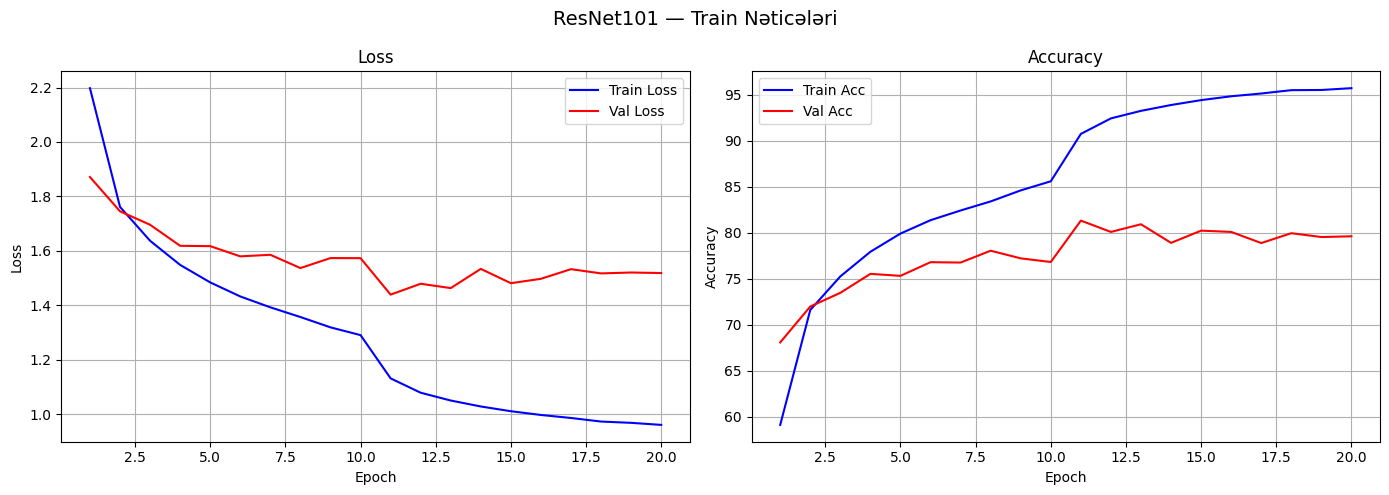

In [14]:
fig , axes = plt.subplots(1 , 2 , figsize=(14 , 5))
fig.suptitle('ResNet101 — Train Nəticələri', fontsize=14)
axes[0].plot(range(1,NUM_EPOCHS+1) , train_losses,label='Train Loss', color='blue')
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses,   label='Val Loss',   color='red')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, NUM_EPOCHS+1), train_accs, label='Train Acc', color='blue')
axes[1].plot(range(1, NUM_EPOCHS+1), val_accs,   label='Val Acc',   color='red')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

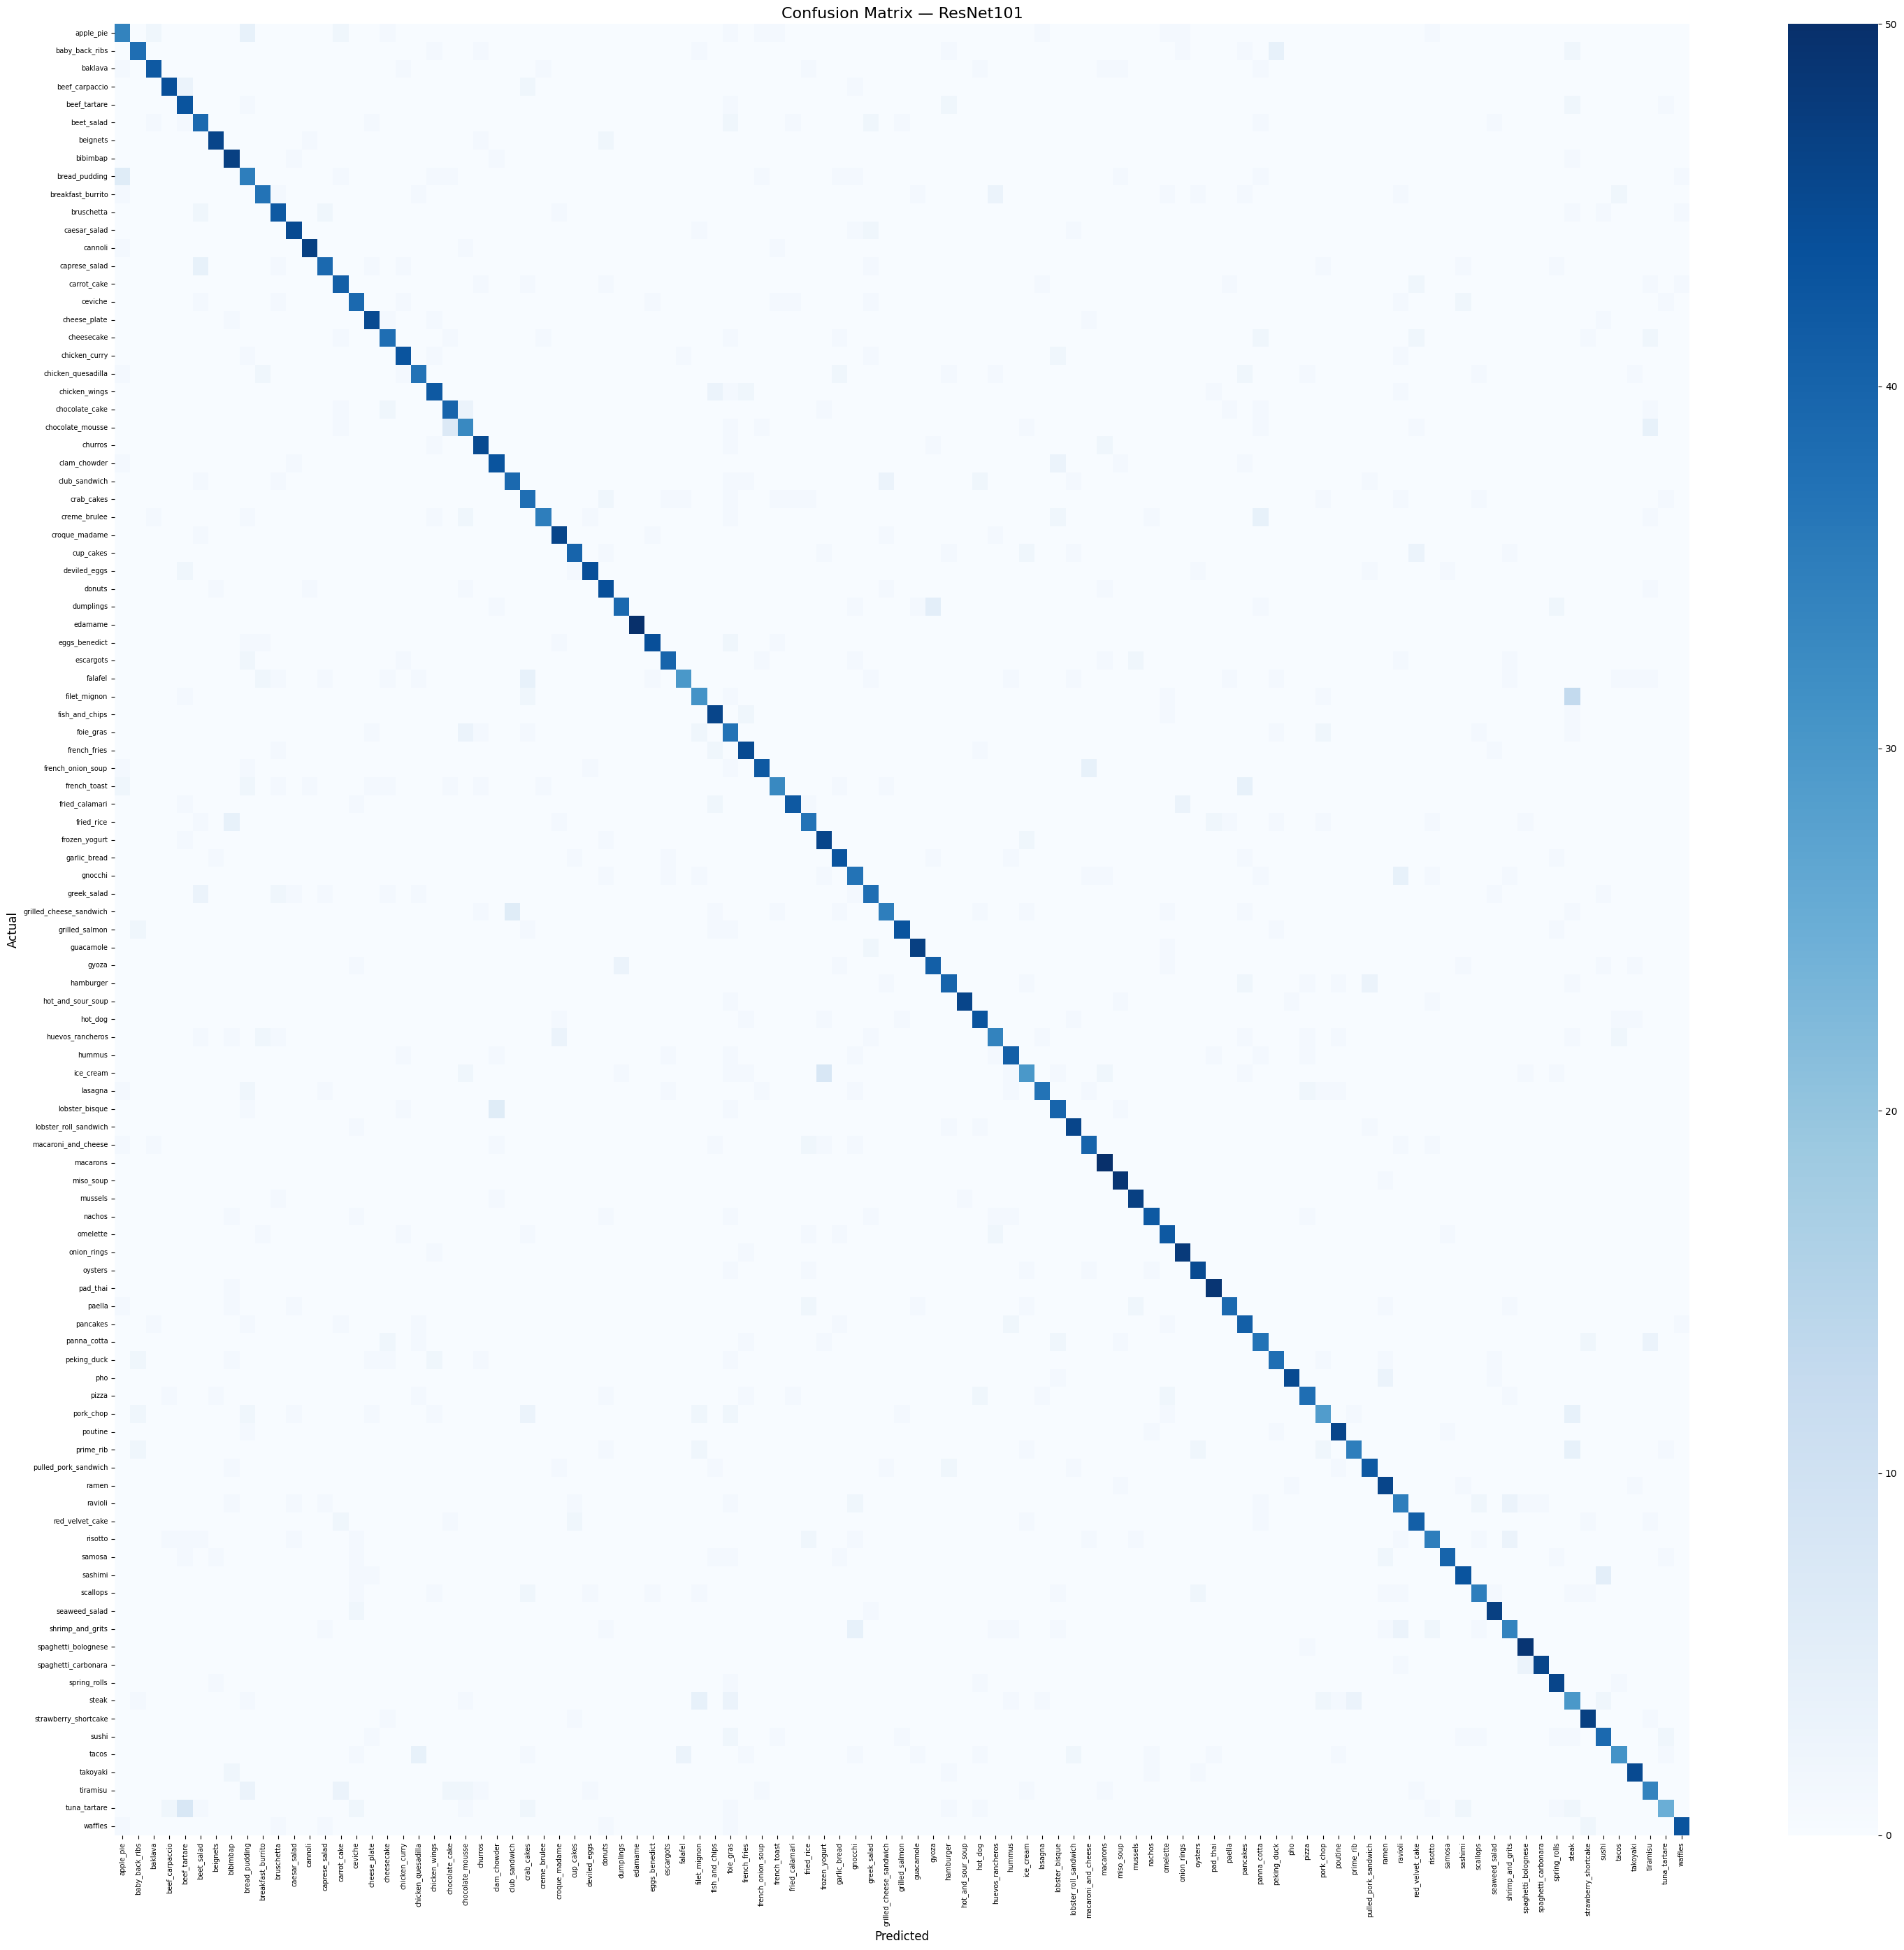


Classification Report:
                         precision    recall  f1-score   support

              apple_pie       0.65      0.68      0.67        50
         baby_back_ribs       0.81      0.76      0.78        50
                baklava       0.88      0.84      0.86        50
         beef_carpaccio       0.92      0.88      0.90        50
           beef_tartare       0.69      0.86      0.77        50
             beet_salad       0.71      0.78      0.74        50
               beignets       0.90      0.92      0.91        50
               bibimbap       0.77      0.94      0.85        50
          bread_pudding       0.59      0.70      0.64        50
      breakfast_burrito       0.82      0.74      0.78        50
             bruschetta       0.78      0.84      0.81        50
           caesar_salad       0.87      0.90      0.88        50
                cannoli       0.94      0.94      0.94        50
          caprese_salad       0.83      0.78      0.80        50


In [17]:
model.load_state_dict(torch.load('resnet101_best_model.pth'))
model.eval()

all_preds   = []
all_targets = []

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs  = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())   #![[76, 23, 45]] appendde netice bele cixir diye bunu etmirik onun yerine extend edirik onun neticesi ise: [12, 55, 88]

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(30, 28))
sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=val_data.classes,
    yticklabels=val_data.classes
)
plt.title('Confusion Matrix — ResNet101', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual',    fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    all_targets,
    all_preds,
    target_names=val_data.classes
))